In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv('../.env')

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

if DB_PASSWORD:
    CONNECTION_STRING = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
else:
    CONNECTION_STRING = f"postgresql://{DB_USER}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

engine = create_engine(CONNECTION_STRING)
print("Connected to database successfully.")

Matplotlib is building the font cache; this may take a moment.


Connected to database successfully.


In [2]:
# Load the full fact table with all dimension data joined
df = pd.read_sql("""
    SELECT
        dc.coin_name,
        dc.symbol,
        dd.full_date,
        dd.year,
        dd.month_name,
        dd.quarter,
        f.current_price,
        f.market_cap,
        f.total_volume,
        f.price_change_24h,
        f.price_change_pct_24h,
        f.loaded_at
    FROM warehouse.fact_crypto_prices f
    JOIN warehouse.dim_coin dc ON dc.coin_id = f.coin_id
    JOIN warehouse.dim_date dd ON dd.date_key = f.date_key
    ORDER BY dd.full_date DESC, f.market_cap DESC
""", engine)

print(f"Total rows: {len(df)}")
print(f"Date range: {df['full_date'].min()} to {df['full_date'].max()}")
df.head(10)

Total rows: 10
Date range: 2026-06-10 to 2026-06-10


,coin_name,symbol,full_date,year,month_name,quarter,current_price,market_cap,total_volume,price_change_24h,price_change_pct_24h,loaded_at
0,Bitcoin,btc,2026-06-10,2026,June,2,61231.000000,1.226558e+12,3.779546e+10,-1956.505905,-3.0963,2026-06-10 10:51:14.681085
1,Bitcoin,btc,2026-06-10,2026,June,2,61186.000000,1.226460e+12,3.761741e+10,-2210.407011,-3.4867,2026-06-10 11:09:36.016161
2,Ethereum,eth,2026-06-10,2026,June,2,1624.540000,1.960245e+11,1.368955e+10,-59.699081,-3.5446,2026-06-10 10:51:14.681085
3,Ethereum,eth,2026-06-10,2026,June,2,1622.340000,1.959126e+11,1.383981e+10,-68.254607,-4.0373,2026-06-10 11:09:36.016161
4,BNB,bnb,2026-06-10,2026,June,2,585.310000,7.891908e+10,7.270924e+08,-18.793839,-3.1110,2026-06-10 11:09:36.016161
5,BNB,bnb,2026-06-10,2026,June,2,584.820000,7.883801e+10,6.895436e+08,-16.739827,-2.7827,2026-06-10 10:51:14.681085
6,Solana,sol,2026-06-10,2026,June,2,64.240000,3.721555e+10,2.858044e+09,-2.788130,-4.1596,2026-06-10 10:51:14.681085
7,Solana,sol,2026-06-10,2026,June,2,64.070000,3.712727e+10,2.714622e+09,-3.087349,-4.5975,2026-06-10 11:09:36.016161
8,Cardano,ada,2026-06-10,2026,June,2,0.161449,5.998552e+09,4.237326e+08,-0.006572,-3.9113,2026-06-10 10:51:14.681085
9,Cardano,ada,2026-06-10,2026,June,2,0.160851,5.981986e+09,4.115128e+08,-0.008892,-5.2384,2026-06-10 11:09:36.016161


In [3]:
# Check for missing values in every column
print("=== NULL CHECK ===")
null_counts = df.isnull().sum()
print(null_counts)
print(f"\nTotal null values: {null_counts.sum()}")

=== NULL CHECK ===
coin_name               0
symbol                  0
full_date               0
year                    0
month_name              0
quarter                 0
current_price           0
market_cap              0
total_volume            0
price_change_24h        0
price_change_pct_24h    0
loaded_at               0
dtype: int64

Total null values: 0


In [4]:
# Check for duplicate records — same coin on the same date loaded twice
print("=== DUPLICATE CHECK ===")
duplicates = df[df.duplicated(subset=['coin_name', 'full_date', 'loaded_at'], keep=False)]
print(f"Duplicate rows found: {len(duplicates)}")

if len(duplicates) > 0:
    print(duplicates)
else:
    print("No duplicates found.")

=== DUPLICATE CHECK ===
Duplicate rows found: 0
No duplicates found.


In [5]:
# Verify every column has the correct data type
print("=== DATA TYPE CHECK ===")
print(df.dtypes)

=== DATA TYPE CHECK ===
coin_name                       object
symbol                          object
full_date                       object
year                             int64
month_name                      object
quarter                          int64
current_price                  float64
market_cap                     float64
total_volume                   float64
price_change_24h               float64
price_change_pct_24h           float64
loaded_at               datetime64[ns]
dtype: object


In [6]:
# Convert full_date from string to proper date type
df['full_date'] = pd.to_datetime(df['full_date'])

print("=== DATA TYPES AFTER FIX ===")
print(df.dtypes)

=== DATA TYPES AFTER FIX ===
coin_name                       object
symbol                          object
full_date               datetime64[ns]
year                             int64
month_name                      object
quarter                          int64
current_price                  float64
market_cap                     float64
total_volume                   float64
price_change_24h               float64
price_change_pct_24h           float64
loaded_at               datetime64[ns]
dtype: object


In [7]:
# Statistical summary of all numeric columns
print("=== STATISTICAL SUMMARY ===")
df[['current_price', 'market_cap', 'total_volume', 'price_change_pct_24h']].describe().round(2)

=== STATISTICAL SUMMARY ===


,current_price,market_cap,total_volume,price_change_pct_24h
count,10.00,1.000000e+01,1.000000e+01,10.00
mean,12696.26,3.089036e+11,1.107668e+10,-3.80
std,25575.54,4.883670e+11,1.495353e+10,0.75
min,0.16,5.981986e+09,4.115128e+08,-5.24
25%,64.11,3.714934e+10,6.989308e+08,-4.13
50%,585.07,7.887854e+10,2.786333e+09,-3.73
75%,1623.99,1.959965e+11,1.380224e+10,-3.20
max,61231.00,1.226558e+12,3.779546e+10,-2.78


=== PRICE DISTRIBUTION ===


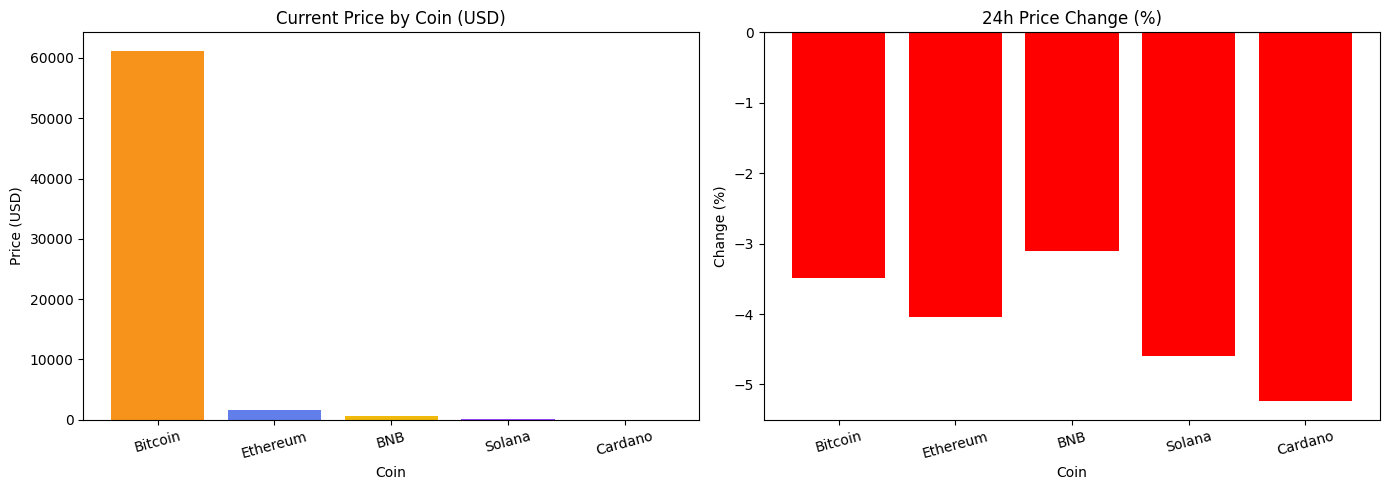

Chart saved to images/price_distribution.png


In [8]:
# Visualize price distribution across coins
print("=== PRICE DISTRIBUTION ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Current price by coin (latest snapshot only)
latest = df[df['loaded_at'] == df['loaded_at'].max()]
axes[0].bar(latest['coin_name'], latest['current_price'], color=['#F7931A', '#627EEA', '#F0B90B', '#9945FF', '#0033AD'])
axes[0].set_title('Current Price by Coin (USD)')
axes[0].set_xlabel('Coin')
axes[0].set_ylabel('Price (USD)')
axes[0].tick_params(axis='x', rotation=15)

# Chart 2 — 24h price change percentage
colors = ['green' if x > 0 else 'red' for x in latest['price_change_pct_24h']]
axes[1].bar(latest['coin_name'], latest['price_change_pct_24h'], color=colors)
axes[1].set_title('24h Price Change (%)')
axes[1].set_xlabel('Coin')
axes[1].set_ylabel('Change (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../images/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images/price_distribution.png")

=== MARKET CAP DISTRIBUTION ===


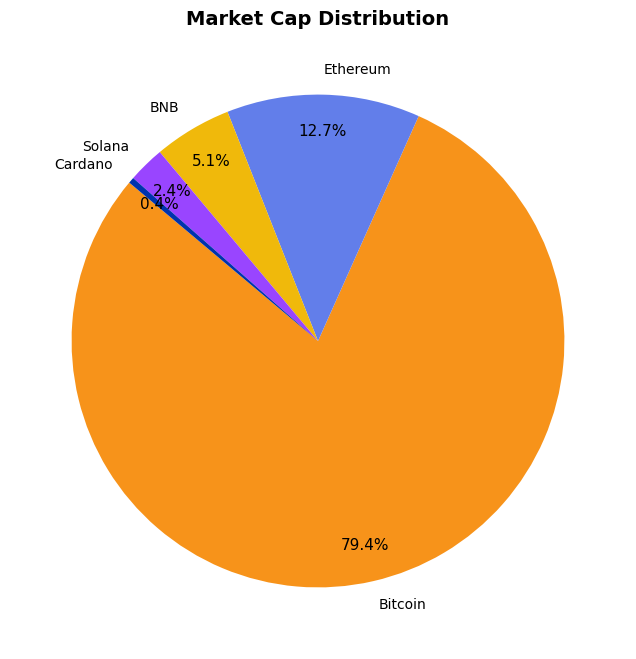

Chart saved to images/market_cap_distribution.png


In [9]:
# Market cap comparison — who dominates the market
print("=== MARKET CAP DISTRIBUTION ===")

latest = df[df['loaded_at'] == df['loaded_at'].max()]

fig, ax = plt.subplots(figsize=(8, 8))

colors = ['#F7931A', '#627EEA', '#F0B90B', '#9945FF', '#0033AD']
wedges, texts, autotexts = ax.pie(
    latest['market_cap'],
    labels=latest['coin_name'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.85
)

for text in autotexts:
    text.set_fontsize(11)

ax.set_title('Market Cap Distribution', fontsize=14, fontweight='bold')

plt.savefig('../images/market_cap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images/market_cap_distribution.png")

In [10]:
# Final data quality report — summary of all checks
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)
print(f"Total rows:              {len(df)}")
print(f"Total coins tracked:     {df['coin_name'].nunique()}")
print(f"Date range:              {df['full_date'].min().date()} to {df['full_date'].max().date()}")
print(f"Pipeline runs recorded:  {df['loaded_at'].nunique()}")
print(f"Null values:             {df.isnull().sum().sum()}")
print(f"Duplicate rows:          {df.duplicated(subset=['coin_name','full_date','loaded_at']).sum()}")
print(f"Negative prices:         {(df['current_price'] <= 0).sum()}")
print(f"Negative market caps:    {(df['market_cap'] <= 0).sum()}")
print(f"Negative volumes:        {(df['total_volume'] <= 0).sum()}")
print("=" * 50)

# Overall verdict
critical_issues = (
    df.isnull().sum().sum() +
    df.duplicated(subset=['coin_name','full_date','loaded_at']).sum() +
    (df['current_price'] <= 0).sum() +
    (df['market_cap'] <= 0).sum()
)

if critical_issues == 0:
    print("STATUS: PASSED — Data is clean and ready for Power BI")
else:
    print(f"STATUS: FAILED — {critical_issues} critical issues found")
print("=" * 50)

DATA QUALITY REPORT
Total rows:              10
Total coins tracked:     5
Date range:              2026-06-10 to 2026-06-10
Pipeline runs recorded:  2
Null values:             0
Duplicate rows:          0
Negative prices:         0
Negative market caps:    0
Negative volumes:        0
STATUS: PASSED — Data is clean and ready for Power BI
